# 01 - The four bridge states

## Purpose

This notebook is the second in a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. Notebook
00 characterized the measurement chain. This notebook establishes what the
H-bridge does to the measured channels in each of its four output states,
so that later notebooks can gate every sample on the state the bridge was
in when the sample was taken.

This notebook has three jobs:

1. Establish, from data, what each bridge state does to the terminal
   voltages, the shunt current and the motion (section 5).
2. Produce the per-state sample-validity map that the later notebooks gate
   on (section 5.4).
3. Measure the coast and brake spin-down behavior (section 6).

The dataset is one test series on a 2-cell lithium battery, each recording
made of three sweeps captured back to back.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebook 00, summarized here with the additions this
notebook needs.

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned. The bridge has four output states. **Forward drive** and
  **reverse drive** connect the supply across the motor in either
  polarity. **Brake** pulls both outputs low, so the winding is shorted
  through the two low-side switches. **Coast** turns every switch off, so
  both terminals float.
- **Duty** is the fraction of each PWM period in the drive state. The
  **decay mode** selects what the bridge does for the rest of the period.
  Under **slow decay** the OFF portion is brake. Under **fast decay** the
  OFF portion is coast.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts here (angle calibration is a later notebook).
- A 33 mOhm shunt resistor in the motor return path, amplified with gain
  15.0, gives the motor current channel. The recorded value is the
  amplifier output at the ADC pin, offset included. Current crosses the
  shunt only while the bridge drives. In brake the current recirculates
  through the low-side switches. In coast it returns through the switch
  body diodes, crossing the shunt in the negative direction until it dies.
- Both motor terminals are read through 20 kOhm / 10 kOhm resistor
  dividers, channels `vmotor_a` and `vmotor_b`. Each divider loads its
  terminal with 30 kOhm to ground. A terminal that swings below ground is
  clamped by the pin's protection diode.
- The ADC runs two five-channel scans per 50 us period, one triggered at
  the crest of the PWM counter and one at the trough. Under slow decay the
  drive window is centered on the crest. Under fast decay it is centered
  on the trough. Section 5.1 works out which scan sees which state.
- The controller streams one frame per period, with the crest scan's
  shunt, both terminals and position, plus the trough scan's shunt. Every
  frame carries a CRC. Corrupted frames are dropped and counted, so
  corruption turns into missing samples (verified in section 4).

Power is a 2-cell lithium battery, nominal 7.4 V, measured at the driven
terminal in section 5.2.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
the same as notebook 00.

| Quantity | Value |
|---|---|
| ADC resolution | 12 bit (0..4095 counts) |
| ADC reference | VDD, nominal 3.300 V |
| Motor terminal divider | 20 kOhm top / 10 kOhm bottom |
| Current shunt | 33 mOhm |
| Current amplifier gain | 15.0 |
| Control period | 50 us (20 kHz) |
| PWM counter | 1200 timer ticks per half period, center aligned |
| Duty encoding | signed, 32767 = 100% |
| Current sampling floor | 160 timer ticks = 13.3% duty |
| Voltage sampling floor | 210 timer ticks = 17.5% duty |

A duty $d$ places the drive window with half-width $1200 d$ ticks around
its center and the OFF window with half-width $1200 (1 - d)$ ticks around
the opposite extreme of the counter. The sampling floors state how far
inside a window the scan must sit for the sample to be settled. They apply
to both windows. A drive-window sample is settled for $d \geq 13.3\%$
(current) and $d \geq 17.5\%$ (voltage). An OFF-window sample is settled
for $d \leq 86.7\%$ (current) and $d \leq 82.5\%$ (voltage). The streamed
`window_valid` flag encodes the current floor of the drive window.

Two caveats carry over from notebook 00. The ADC reference is the design
value, so every voltage scales with the true VDD of this unit. The
divider, shunt and gain are design values with unmeasured tolerances.

The derived conversion factors:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import least_squares

# --- documented constants (see the table above) ---
VDD_V = 3.300               # ADC reference, nominal, not measured
ADC_COUNTS = 4096           # 12-bit converter
DIV_TOP_OHM = 20_000        # motor terminal divider, top leg
DIV_BOT_OHM = 10_000        # motor terminal divider, bottom leg
SHUNT_OHM = 0.033           # current shunt
AMP_GAIN = 15.0             # current amplifier gain
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire
FLOOR_I_TICKS = 160         # current sampling floor
FLOOR_V_TICKS = 210         # voltage sampling floor

# --- derived conversion factors ---
V_ADC_PER_COUNT = VDD_V / ADC_COUNTS                       # volts at the ADC pin
V_TERM_PER_COUNT = V_ADC_PER_COUNT * (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM
A_PER_COUNT = V_ADC_PER_COUNT / (AMP_GAIN * SHUNT_OHM)     # amps through the shunt
FLOOR_I_PCT = FLOOR_I_TICKS * 100.0 / PWM_HALF_TICKS
FLOOR_V_PCT = FLOOR_V_TICKS * 100.0 / PWM_HALF_TICKS

pd.DataFrame([
    {"quantity": "pot wiper", "value": V_ADC_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "motor terminal", "value": V_TERM_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "motor current", "value": A_PER_COUNT * 1e3, "unit": "mA per count"},
    {"quantity": "drive window settled, current", "value": FLOOR_I_PCT, "unit": "% duty and above"},
    {"quantity": "drive window settled, voltage", "value": FLOOR_V_PCT, "unit": "% duty and above"},
    {"quantity": "OFF window settled, current", "value": 100 - FLOOR_I_PCT, "unit": "% duty and below"},
    {"quantity": "OFF window settled, voltage", "value": 100 - FLOOR_V_PCT, "unit": "% duty and below"},
]).set_index("quantity").round(4)


,value,unit
quantity,,
pot wiper,0.8057,mV per count
motor terminal,2.4170,mV per count
motor current,1.6276,mA per count
"drive window settled, current",13.3333,% duty and above
"drive window settled, voltage",17.5000,% duty and above
"OFF window settled, current",86.6667,% duty and below
"OFF window settled, voltage",82.5000,% duty and below


## 3. Capture method

The recordings live in the repository under `notebooks/telemetry/sg90/bridge/`,
one folder per recording. Each recording holds three sweeps, captured back
to back with the same servo state:

- **Slow-decay sweep.** Segment 0 is a one-second baseline with the bridge
  disabled. Segments 1 to 40 are 80 ms drive steps at constant duty, 5% to
  100% in 5% increments, first forward then reverse, under slow decay.
- **Fast-decay sweep.** The same grid under fast decay.
- **Spin-down sweep.** Slow decay. Segment 0 is the baseline. Then, for
  20%, 30% and 40% duty in turn, an 80 ms drive step followed by 400 ms of
  coast, and a second drive step at the same duty followed by 400 ms of
  brake. The pattern runs forward first, then reverse, 24 segments in all.
  The zero-duty segments start when the drive command ends, so the motor
  enters them at whatever speed the drive step reached.

Before every drive step the servo is repositioned at 15% duty toward the
far end of travel, so the step has room to accelerate. The mechanism can
still be moving from that repositioning move when the step begins, in the
direction opposite to the step. Speed at the end of a drive step therefore
varies from step to step, and the entry speed into every coast and brake
segment is measured from the data (section 6).

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames in all three sweeps. Section 4 re-verifies this from the
data itself.

Each row of a sweep is one 50 us sample: segment number, commanded duty,
direction, tick counter, the firmware's validity flag, position, the
crest-scan shunt (`current_raw`), the trough-scan shunt
(`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`). The spin-down sweep's metadata lists the schedule, from which
the kind of every zero-duty segment (coast or brake) follows.


In [2]:
TELEMETRY = Path("telemetry/sg90/bridge")
SWEEPS = ("slow", "fast", "spindown")

def load_sweep(rec_dir, name):
    df = pd.read_csv(rec_dir / f"{name}.csv.gz")
    meta = json.loads((rec_dir / f"{name}.meta.json").read_text())
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    df["bias"] = df.loc[df["seg"] == 0, "current_raw"].mean()
    if name == "spindown":
        # Segment k (k >= 1) is schedule entry (k - 1) mod len(schedule).
        sched = meta["schedule"]
        kinds = ["baseline"] + [
            "drive" if ":" not in s else s.split(":")[0]
            for s in sched * (df["seg"].max() // len(sched))
        ]
        df["kind"] = df["seg"].map(dict(enumerate(kinds)))
    return df, meta

recs = {}
for d in sorted(TELEMETRY.glob("capture-*"), key=lambda p: int(p.name.split("-")[1])):
    recs[d.name] = {name: load_sweep(d, name) for name in SWEEPS}

pd.DataFrame({
    "recordings": [len(recs)],
    "sweeps per recording": [len(SWEEPS)],
}, index=["2s battery"])


,recordings,sweeps per recording
2s battery,5,3


## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every sweep in every recording from
the tick column, which increments by one per sample within a segment.


In [3]:
rows = []
for name, sweeps in recs.items():
    for sweep, (df, meta) in sweeps.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({
            "recording": name,
            "sweep": sweep,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
        })
pd.DataFrame(rows).set_index(["recording", "sweep"])


samples  segments  missing_samples
recording sweep                                       
capture-1 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-2 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-3 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-4 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-5 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0

Every sweep of every recording has zero missing samples.

## 5. The four states

### 5.1 Which scan sees which state

The two scans per period sit at the two extremes of the center-aligned
PWM counter. The drive window is centered on the crest under slow decay
and on the trough under fast decay, so each scan sees a different bridge
state depending on the decay mode:

| Decay | Crest scan (`current_raw`, `vmotor_a`, `vmotor_b`) | Trough scan (`current_trough`) |
|---|---|---|
| Slow | drive | brake |
| Fast | coast | drive |

Only the shunt is streamed from the trough scan, so the terminal voltages
of the brake state come from the spin-down sweep's brake segments (a brake
state lasting the whole period, seen by the crest scan) and the terminal
voltages of the coast state come from the fast-decay sweep's crest scan
and the spin-down sweep's coast segments. The rest of section 5 checks
each cell of this table against the data.

### 5.2 Slow decay

Under slow decay the crest scan reads the drive state. The figure shows
the crest-scan shunt current (bias subtracted, converted to amperes) and
the two terminals against duty, per recording, for both directions. The
trough scan reads the brake state, and its shunt reading is plotted as an
offset from the baseline bias.

Per drive step the terminal levels are the median of the step, and the
current is the median of the step's flagged-valid samples.


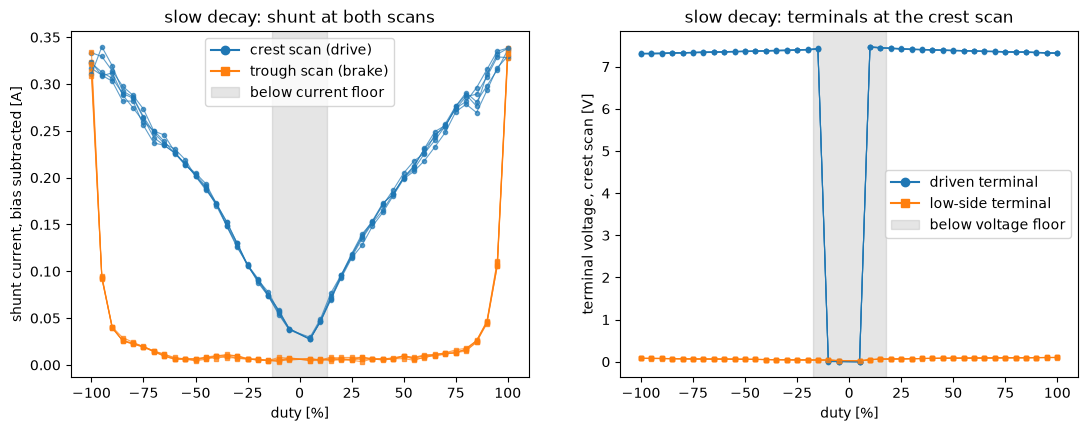

,valid_frac,crest_current_A,trough_offset_counts,driven_terminal_V,lowside_terminal_V
mag_pct,,,,,
5,0.000,0.033,3.766,0.003,0.022
10,0.000,0.052,3.316,3.737,0.044
15,0.999,0.073,3.416,7.436,0.051
20,0.999,0.093,3.716,7.420,0.054
30,0.999,0.132,4.716,7.400,0.060
50,0.999,0.202,4.516,7.374,0.071
70,0.999,0.250,8.216,7.352,0.078
80,0.999,0.284,12.116,7.337,0.082
85,0.999,0.286,15.916,7.336,0.084


In [4]:
def slow_steps(df):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        hi, lo = ("vmotor_a", "vmotor_b") if d > 0 else ("vmotor_b", "vmotor_a")
        out.append({
            "duty_pct": d,
            "mag_pct": int(round(abs(d))),
            "valid_frac": seg["window_valid"].mean(),
            "crest_current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * A_PER_COUNT,
            "trough_offset_counts": seg["current_trough"].median() - seg["bias"].iloc[0],
            "driven_terminal_V": seg[hi].median() * V_TERM_PER_COUNT,
            "lowside_terminal_V": seg[lo].median() * V_TERM_PER_COUNT,
        })
    return pd.DataFrame(out).sort_values("duty_pct")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, sweeps in recs.items():
    st = slow_steps(sweeps["slow"][0])
    axes[0].plot(st["duty_pct"], st["crest_current_A"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[0].plot(st["duty_pct"], st["trough_offset_counts"] * A_PER_COUNT, "-s", ms=3,
                 lw=0.8, color="tab:orange", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["driven_terminal_V"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["lowside_terminal_V"], "-s", ms=3, lw=0.8,
                 color="tab:orange", alpha=0.7)
axes[0].plot([], [], "-o", color="tab:blue", label="crest scan (drive)")
axes[0].plot([], [], "-s", color="tab:orange", label="trough scan (brake)")
axes[0].axvspan(-FLOOR_I_PCT, FLOOR_I_PCT, color="grey", alpha=0.2, label="below current floor")
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("shunt current, bias subtracted [A]")
axes[0].set_title("slow decay: shunt at both scans")
axes[0].legend()
axes[1].plot([], [], "-o", color="tab:blue", label="driven terminal")
axes[1].plot([], [], "-s", color="tab:orange", label="low-side terminal")
axes[1].axvspan(-FLOOR_V_PCT, FLOOR_V_PCT, color="grey", alpha=0.2, label="below voltage floor")
axes[1].set_xlabel("duty [%]")
axes[1].set_ylabel("terminal voltage, crest scan [V]")
axes[1].set_title("slow decay: terminals at the crest scan")
axes[1].legend()
plt.show()

# Pooled over recordings and directions, by duty magnitude.
allst = pd.concat([slow_steps(s["slow"][0]) for s in recs.values()])
(allst.groupby("mag_pct")[["valid_frac", "crest_current_A", "trough_offset_counts",
                            "driven_terminal_V", "lowside_terminal_V"]]
      .mean().round(3).iloc[[0, 1, 2, 3, 5, 9, 13, 15, 16, 17, 18, 19]])


Findings for the drive state (crest scan):

- The shunt current rises with duty from the first step. The validity flag
  sets from the 15% step in every recording, the first grid point above
  the 13.3% floor. The current curve passes through the flag edge without
  a kink.
- The driven terminal reads the supply rail, about 7.4 V, from the 10%
  step forward and the 15% step in reverse. The reverse edge is one grid
  step later because terminal B is the later of the two terminal slots in
  the scan. The 17.5% voltage floor covers both edges. The rail sags by
  about 0.12 V from 15% to 100% duty.
- The low-side terminal rises from 0.02 V to 0.10 V with current. Its slope
  against the shunt current is about 0.18 Ohm, the on-resistance of the
  low-side switch plus the shunt.

Findings for the brake state (trough scan):

- The trough shunt sits within 20 counts (0.03 A equivalent) of the
  baseline bias up to the 85% step, with a small offset that grows with
  duty (a few counts at low duty, about 16 counts at 85%). *Hypothesis
  (not tested here): the offset is the amplifier still recovering from the
  drive pulse.*
- At 90% and 95% the trough reading climbs toward the drive current, and
  at 100% the two scans read the same value, because there is no OFF
  window left. This matches the 86.7% OFF-window floor from section 2.

The brake state's terminal voltages come from the spin-down sweep in
section 6. Both terminals sit at a few counts above ground for the whole
brake segment (table in section 5.4).

### 5.3 Fast decay

Under fast decay the trough scan reads the drive state and the crest scan
reads the coast state. The left panel shows the shunt at both scans. The
right panel shows the sum of the two crest-scan terminals, $v_A + v_B$,
which serves as the phase discriminator of the coast window. During coast
one terminal is clamped near ground by its protection diode, so the sum
equals whichever terminal is positive. The measured rail (section 5.2) is
drawn as the discriminator threshold. A floating terminal cannot exceed
the rail. A terminal reading above it is being held there by a conducting
high-side body diode, which means winding current is still flowing.


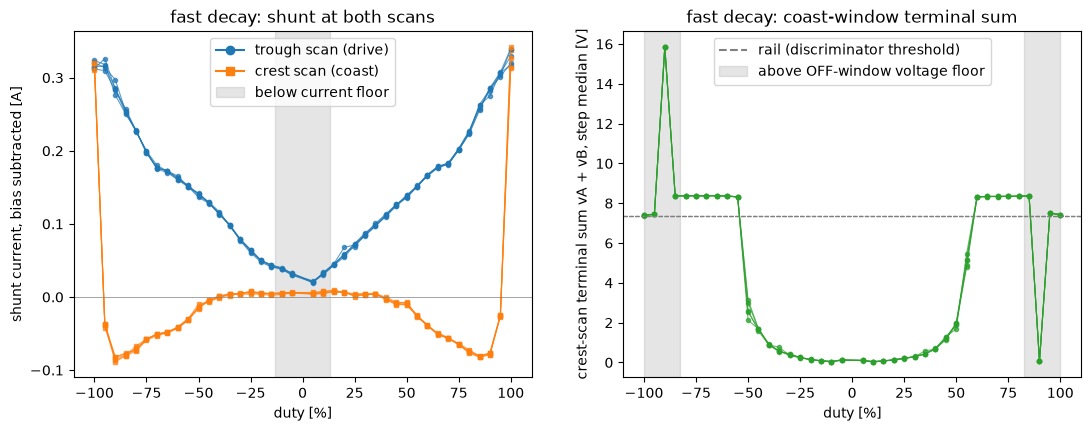

,valid_frac,trough_current_A,crest_current_A,sum_median_V,diode_frac,travel_mV
mag_pct,,,,,,
5,0.000,0.026,0.005,0.112,0.000,-70.052
10,0.000,0.036,0.006,0.042,0.000,0.403
15,0.999,0.044,0.006,0.081,0.000,-0.040
20,0.999,0.054,0.006,0.137,0.000,-0.121
25,0.999,0.067,0.004,0.229,0.000,0.000
30,0.999,0.082,0.004,0.339,0.000,11.481
35,0.999,0.098,0.004,0.532,0.000,38.229
40,0.999,0.113,-0.001,0.790,0.000,82.057
45,0.999,0.127,-0.007,1.444,0.010,48.219


In [5]:
def rail_V(sweeps):
    # Supply rail per recording: median driven terminal over the valid
    # slow-decay drive steps at 20% and above.
    df = sweeps["slow"][0]
    v = df[(df["seg"] > 0) & (df["window_valid"] == 1) & (df["mag_pct"] >= 20)]
    driven = np.where(v["duty_pct"] > 0, v["vmotor_a"], v["vmotor_b"])
    return np.median(driven) * V_TERM_PER_COUNT

def fast_steps(df, rail):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        ssum = (seg["vmotor_a"] + seg["vmotor_b"]) * V_TERM_PER_COUNT
        p = seg["pos"].to_numpy() * V_ADC_PER_COUNT
        out.append({
            "duty_pct": d,
            "mag_pct": int(round(abs(d))),
            "valid_frac": seg["window_valid"].mean(),
            "trough_current_A": (seg["current_trough"].median() - seg["bias"].iloc[0]) * A_PER_COUNT,
            "crest_current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * A_PER_COUNT,
            "sum_median_V": ssum.median(),
            "diode_frac": (ssum > rail).mean(),
            "travel_mV": (np.median(p[-20:]) - np.median(p[:20])) * 1e3 * np.sign(d),
        })
    return pd.DataFrame(out).sort_values("duty_pct")

rails = {name: rail_V(sweeps) for name, sweeps in recs.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, sweeps in recs.items():
    st = fast_steps(sweeps["fast"][0], rails[name])
    axes[0].plot(st["duty_pct"], st["trough_current_A"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[0].plot(st["duty_pct"], st["crest_current_A"], "-s", ms=3, lw=0.8,
                 color="tab:orange", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["sum_median_V"], "-o", ms=3, lw=0.8,
                 color="tab:green", alpha=0.7)
    axes[1].axhline(rails[name], color="grey", lw=0.8, ls="--")
axes[0].plot([], [], "-o", color="tab:blue", label="trough scan (drive)")
axes[0].plot([], [], "-s", color="tab:orange", label="crest scan (coast)")
axes[0].axhline(0, color="grey", lw=0.5)
axes[0].axvspan(-FLOOR_I_PCT, FLOOR_I_PCT, color="grey", alpha=0.2, label="below current floor")
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("shunt current, bias subtracted [A]")
axes[0].set_title("fast decay: shunt at both scans")
axes[0].legend()
axes[1].plot([], [], "--", color="grey", label="rail (discriminator threshold)")
axes[1].axvspan(-100, -(100 - FLOOR_V_PCT), color="grey", alpha=0.2)
axes[1].axvspan(100 - FLOOR_V_PCT, 100, color="grey", alpha=0.2,
                label="above OFF-window voltage floor")
axes[1].set_xlabel("duty [%]")
axes[1].set_ylabel("crest-scan terminal sum vA + vB, step median [V]")
axes[1].set_title("fast decay: coast-window terminal sum")
axes[1].legend(loc="upper center")
plt.show()

allft = pd.concat([fast_steps(s["fast"][0], rails[n]) for n, s in recs.items()])
(allft.groupby("mag_pct")[["valid_frac", "trough_current_A", "crest_current_A",
                            "sum_median_V", "diode_frac", "travel_mV"]]
      .mean().round(3))


Findings for the drive state (trough scan):

- The trough shunt reads the drive current, rising monotonically from 5%
  to 100%, and the validity flag sets from the 15% step as under slow
  decay. The same floor applies to both decay modes.

Findings for the coast state (crest scan), by duty range:

- **5% to 30%.** The crest shunt reads the bias within 5 counts. The
  terminal sum is small and grows with duty. The position column shows no
  net motion up to 25%. *Hypothesis (not tested here): the drive pulse is
  too short for the current to build against the winding inductance, so
  conduction is discontinuous and the average torque falls below the
  friction threshold.*
- **60% to 85%.** The terminal sum sits about 1.0 V above the rail in
  most samples of each step, and the 55% step is mixed. This is the diode
  phase. Winding current is still flowing when the scan fires, returning
  through the high-side body diode of the terminal that was driven low,
  which holds that terminal one diode drop above the rail. The crest shunt
  reads below the bias in the same range, the freewheel current crossing
  the shunt backward, growing from 0.04 A at 60% to 0.08 A at 85%.
- **35% to 50%.** The terminal sum rises steeply from 0.5 V to about
  2.3 V with no sample above the rail. The next code cell examines what
  this reading is.
- **90% and 95%.** The OFF window is narrower than the terminal slots'
  offset from the crest, so the terminal samples land partly inside the
  drive window and mix the two states. In the reverse 90% step one
  terminal reads the diode level and the other the drive level, which
  puts the sum far above the rail. This is the 82.5% OFF-window voltage
  floor from section 2. At 100% both scans read the drive state.

The terminal reading in the 35% to 50% range needs a closer look. If it
were the back-EMF of a spinning motor, it would grow with speed within a
step as the motor accelerates, and it would appear on the terminal that
was driven high, the polarity the coast segments of section 6.1 show. The
figure follows one step at 45% duty through its 80 ms.


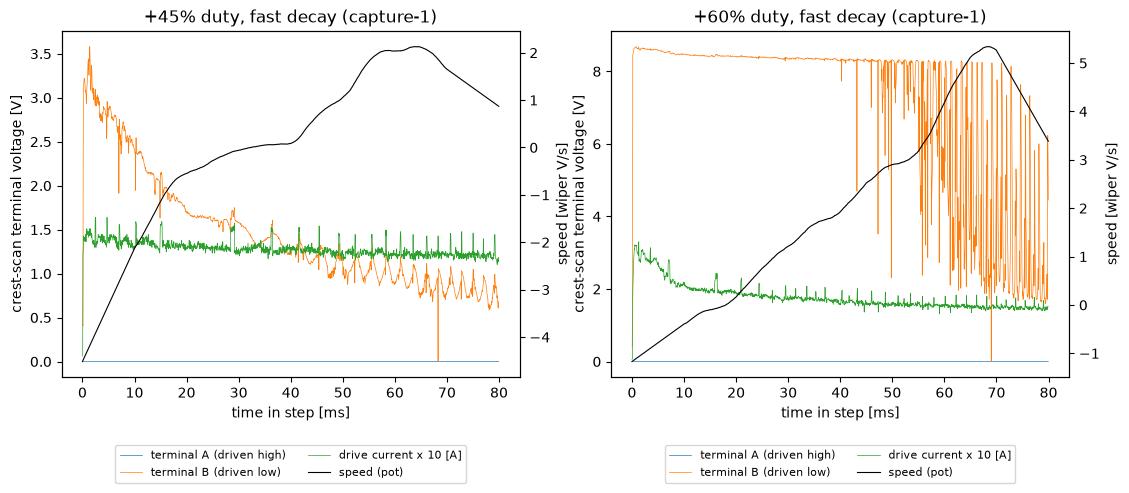

,speed_Vps,terminal_B_V,terminal_A_V,drive_current_A
quarter,,,,
1,-1.207,2.269,0.0,0.135
2,0.095,1.417,0.0,0.127
3,1.058,1.061,0.0,0.124
4,1.799,0.814,0.0,0.121


In [6]:
name, sweeps = next(iter(recs.items()))
df = sweeps["fast"][0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, pct in zip(axes, [45, 60]):
    seg = df[np.isclose(df["duty_pct"], pct, atol=0.5)]
    t = (seg["tick"] - seg["tick"].iloc[0]) / (TICK_HZ / 1000)
    p = seg["pos"].to_numpy() * V_ADC_PER_COUNT
    speed = savgol_filter(p, 401, 2, deriv=1, delta=1 / TICK_HZ)
    ax.plot(t, seg["vmotor_a"] * V_TERM_PER_COUNT, lw=0.5, label="terminal A (driven high)")
    ax.plot(t, seg["vmotor_b"] * V_TERM_PER_COUNT, lw=0.5, label="terminal B (driven low)")
    ax.plot(t, (seg["current_trough"] - seg["bias"]) * A_PER_COUNT * 10, lw=0.5,
            label="drive current x 10 [A]")
    ax.set_xlabel("time in step [ms]")
    ax.set_ylabel("crest-scan terminal voltage [V]")
    ax2 = ax.twinx()
    ax2.plot(t, speed, color="k", lw=0.8, label="speed (pot)")
    ax2.set_ylabel("speed [wiper V/s]")
    ax.set_title(f"+{pct}% duty, fast decay ({name})")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper center", bbox_to_anchor=(0.5, -0.18),
              ncol=2, fontsize=8)
plt.show()

# Quarter-by-quarter means of the +45% step, every recording.
rows = []
for name, sweeps in recs.items():
    seg = sweeps["fast"][0]
    seg = seg[np.isclose(seg["duty_pct"], 45, atol=0.5)]
    p = seg["pos"].to_numpy() * V_ADC_PER_COUNT
    speed = savgol_filter(p, 401, 2, deriv=1, delta=1 / TICK_HZ)
    n = len(seg) // 4
    for q in range(4):
        sl = slice(q * n, (q + 1) * n)
        rows.append({
            "recording": name,
            "quarter": q + 1,
            "speed_Vps": speed[sl].mean(),
            "terminal_B_V": seg["vmotor_b"].iloc[sl].median() * V_TERM_PER_COUNT,
            "terminal_A_V": seg["vmotor_a"].iloc[sl].median() * V_TERM_PER_COUNT,
            "drive_current_A": (seg["current_trough"].iloc[sl].median()
                                - seg["bias"].iloc[0]) * A_PER_COUNT,
        })
pd.DataFrame(rows).groupby("quarter")[["speed_Vps", "terminal_B_V", "terminal_A_V",
                                        "drive_current_A"]].mean().round(3)


Within the 45% step the reading on terminal B falls from about 2.3 V to
0.8 V while the speed rises from below zero (residual motion from the
repositioning move) to 1.8 wiper V/s, and the drive current falls
slightly as the motor speeds up. Terminal A, the terminal
driven high, reads zero throughout. In the coast segments of section 6.1
the back-EMF appears on the terminal driven high and grows with speed.
The fast-decay crest reading has the opposite polarity and the opposite
speed dependence, and it is present at 10% to 25% where the motor does
not move at all. It is therefore a residue of the diode phase and carries
no speed information. *Hypothesis (not tested here): after the diode
current dies, the terminal that was held at rail plus one diode drop
discharges through its 30 kOhm divider and the output-node capacitance,
and the scan catches it part way down. The reading grows with duty because
a larger current lengthens the diode phase and leaves less time for the
discharge before the fixed scan instant.*

The consequence for the series is that the fast-decay crest scan delivers
no direct back-EMF sample at any duty in this scan geometry. Direct
back-EMF is available from the coast segments of the spin-down sweep
(section 6.1), where the scan sits hundreds of microseconds after the
current has died.

### 5.4 Validity map

The map below records, for every bridge state and scan, the duty range in
which each channel reads a settled value of that state. The ranges come
from the data of every recording, on the 5% grid of the sweeps. The
data-derived edges are computed first, then assembled with the configured
floors of section 2.


In [7]:
def edges(name, sweeps):
    rail = rails[name]
    slow = sweeps["slow"][0]
    fast = sweeps["fast"][0]
    st = slow_steps(slow)
    ft = fast_steps(fast, rail)
    half_rail_counts = rail / V_TERM_PER_COUNT / 2
    fwd, rev = st[st["duty_pct"] > 0], st[st["duty_pct"] < 0]
    e = {"recording": name}
    e["flag_from_pct"] = int(st[st["valid_frac"] > 0.5]["mag_pct"].min())
    e["terminal_A_from_pct"] = int(fwd[fwd["driven_terminal_V"] > rail / 2]["mag_pct"].min())
    e["terminal_B_from_pct"] = int(rev[rev["driven_terminal_V"] > rail / 2]["mag_pct"].min())
    def both_dirs(tab, cond):
        # Grid points where the condition holds in both directions.
        ok = tab[cond].groupby("mag_pct").size() == 2
        return set(ok[ok].index)
    def run_up_from(ok, start):
        # Last grid point of the contiguous run that starts at `start`.
        pct = start
        while pct + 5 in ok:
            pct += 5
        return pct
    ok = both_dirs(st, st["trough_offset_counts"].abs() <= 20)
    e["trough_bias_to_pct"] = run_up_from(ok, 5)
    ok = both_dirs(ft, ft["crest_current_A"].abs() <= 10 * A_PER_COUNT)
    e["fast_crest_bias_to_pct"] = run_up_from(ok, 5)
    ok = both_dirs(ft, ft["diode_frac"] >= 0.5)
    e["diode_phase_from_pct"] = min(ok)
    e["diode_phase_to_pct"] = run_up_from(ok, min(ok))
    e["rail_V"] = rail
    dl = ft[(ft["mag_pct"] >= e["diode_phase_from_pct"]) & (ft["mag_pct"] <= e["diode_phase_to_pct"])]
    e["diode_level_V"] = dl["sum_median_V"].median()
    # brake terminals, from the spin-down brake segments
    sp = sweeps["spindown"][0]
    br = sp[sp["kind"] == "brake"]
    e["brake_terminal_max_V"] = max(br["vmotor_a"].quantile(0.99),
                                    br["vmotor_b"].quantile(0.99)) * V_TERM_PER_COUNT
    e["brake_shunt_offset_counts"] = br["current_raw"].median() - sp["bias"].iloc[0]
    return e

edge_tab = pd.DataFrame([edges(n, s) for n, s in recs.items()]).set_index("recording")
edge_tab.round(3)


,flag_from_pct,terminal_A_from_pct,terminal_B_from_pct,trough_bias_to_pct,fast_crest_bias_to_pct,diode_phase_from_pct,diode_phase_to_pct,rail_V,diode_level_V,brake_terminal_max_V,brake_shunt_offset_counts
recording,,,,,,,,,,,
capture-1,15,10,15,85,50,60,85,7.374,8.374,0.041,3.651
capture-2,15,10,15,85,50,60,85,7.372,8.370,0.039,3.040
capture-3,15,10,15,85,50,60,85,7.369,8.364,0.041,3.653
capture-4,15,10,15,85,50,60,85,7.365,8.360,0.041,3.992
capture-5,15,10,15,85,50,60,85,7.362,8.356,0.041,3.503


In [8]:
# Conservative over recordings: latest lower edge, earliest upper edge.
def as_edges(s):
    return {k: (int(v) if k.endswith("_pct") else v) for k, v in s.items()}
lo = as_edges(edge_tab.max())
hi = as_edges(edge_tab.min())
rows = [
    ("drive", "slow", "crest", "shunt",
     f">= {FLOOR_I_PCT:.1f}", f"flag from {lo['flag_from_pct']}%",
     "drive current plus bias", "current"),
    ("drive", "slow", "crest", "driven terminal",
     f">= {FLOOR_V_PCT:.1f}", f"A from {lo['terminal_A_from_pct']}%, B from {lo['terminal_B_from_pct']}%",
     "supply rail minus the high-side drop", "supply estimate"),
    ("drive", "slow", "crest", "low-side terminal",
     f">= {FLOOR_V_PCT:.1f}", f"A from {lo['terminal_A_from_pct']}%, B from {lo['terminal_B_from_pct']}%",
     "current times low-side on-resistance plus shunt, about 0.18 Ohm", "switch drop"),
    ("drive", "fast", "trough", "shunt",
     f">= {FLOOR_I_PCT:.1f}", f"flag from {lo['flag_from_pct']}%",
     "drive current plus bias", "current"),
    ("brake", "slow", "trough", "shunt",
     f"<= {100 - FLOOR_I_PCT:.1f}", f"within 20 counts of bias to {hi['trough_bias_to_pct']}%",
     "bias plus a recovery offset growing with duty", "live bias tracker"),
    ("brake", "spin-down segment", "crest", "both terminals",
     "any", f"below {lo['brake_terminal_max_V']:.2f} V in all samples",
     "near ground, winding shorted through the low-side switches", "state check"),
    ("brake", "spin-down segment", "crest", "shunt",
     "any", f"offset {lo['brake_shunt_offset_counts']:.0f} counts",
     "bias, no current through the shunt", "bias"),
    ("coast", "fast", "crest", "shunt",
     f"<= {100 - FLOOR_I_PCT:.1f}", f"within 10 counts of bias to {hi['fast_crest_bias_to_pct']}%",
     "bias where the current has died, negative freewheel current in the diode phase", "bias, diode current"),
    ("coast", "fast", "crest", "terminals, diode phase",
     f"<= {100 - FLOOR_V_PCT:.1f}", f"sum above rail: {lo['diode_phase_from_pct']}% to {hi['diode_phase_to_pct']}%",
     f"rail plus one diode drop ({lo['diode_level_V'] - hi['rail_V']:.2f} V) on the terminal driven low, 0 on the other",
     "phase discriminator only"),
    ("coast", "fast", "crest", "terminals, sum below rail",
     f"<= {100 - FLOOR_V_PCT:.1f}", f"5% to {lo['diode_phase_from_pct'] - 10}%, {lo['diode_phase_from_pct'] - 5}% mixed",
     "diode-phase residue on the terminal driven low, unrelated to speed", "none"),
    ("coast", "spin-down segment", "crest", "positive terminal",
     "any", "from the third sample after the drive ends",
     "direct back-EMF on the terminal that was driven high (section 6.1)", "speed"),
    ("coast", "spin-down segment", "crest", "shunt",
     "any", "from the third sample after the drive ends",
     "bias, no current through the shunt", "bias"),
]
validity_map = pd.DataFrame(rows, columns=[
    "state", "decay or segment", "scan", "channel", "configured duty [%]",
    "measured range", "reads", "use in later notebooks"]).set_index(["state", "decay or segment", "scan", "channel"])
pd.set_option("display.max_colwidth", 90)
validity_map


configured duty [%]  \
state decay or segment  scan   channel                                         
drive slow              crest  shunt                                 >= 13.3   
                               driven terminal                       >= 17.5   
                               low-side terminal                     >= 17.5   
      fast              trough shunt                                 >= 13.3   
brake slow              trough shunt                                 <= 86.7   
      spin-down segment crest  both terminals                            any   
                               shunt                                     any   
coast fast              crest  shunt                                 <= 86.7   
                               terminals, diode phase                <= 82.5   
                               terminals, sum below rail             <= 82.5   
      spin-down segment crest  positive terminal                         any   
                               shunt                                     any   

                                                                                      measured range  \
state decay or segment  scan   channel                                                                 
drive slow              crest  shunt                                                   flag from 15%   
                               driven terminal                                A from 10%, B from 15%   
                               low-side terminal                              A from 10%, B from 15%   
      fast              trough shunt                                                   flag from 15%   
brake slow              trough shunt                                 within 20 counts of bias to 85%   
      spin-down segment crest  both terminals                            below 0.04 V in all samples   
                               shunt                                                 offset 4 counts   
coast fast              crest  shunt                                 within 10 counts of bias to 50%   
                               terminals, diode phase                     sum above rail: 60% to 85%   
                               terminals, sum below rail                        5% to 50%, 55% mixed   
      spin-down segment crest  positive terminal          from the third sample after the drive ends   
                               shunt                      from the third sample after the drive ends   

                                                                                                                                   reads  \
state decay or segment  scan   channel                                                                                                     
drive slow              crest  shunt                                                                             drive current plus bias   
                               driven terminal                                                      supply rail minus the high-side drop   
                               low-side terminal                         current times low-side on-resistance plus shunt, about 0.18 Ohm   
      fast              trough shunt                                                                             drive current plus bias   
brake slow              trough shunt                                                       bias plus a recovery offset growing with duty   
      spin-down segment crest  both terminals                                 near ground, winding shorted through the low-side switches   
                               shunt                                                                  bias, no current through the shunt   
coast fast              crest  shunt                      bias where the current has died, negative freewheel current in the diode phase   
                               terminals, diode phase       rail plus one diode

The measured edges agree with the configured floors on the 5% grid in
every recording, and the diode-phase range confirms the OFF-window
voltage floor from the coast side.

## 6. Spin-down

The spin-down sweep enters each coast or brake segment at the speed the
preceding 80 ms drive step reached. Entry speeds range from about 2 to
11 wiper V/s and vary from step to step (section 3), so coast and brake
are compared through fitted models against measured speed, never by
pairing segments.

### 6.1 Terminal voltage during coast as direct back-EMF

During a coast segment the bridge is off, so once the winding current has
died the terminals carry the motor's back-EMF. The negative terminal is
clamped near ground by its protection diode, and the positive terminal is
the one that was driven high in the preceding drive step. The first two
samples after the drive ends are excluded (the second sample of every
coast segment still shows the diode phase, with the sum above the rail),
and any later sample with the sum above the rail is excluded the same way.

The figure plots the positive terminal against the pot-derived speed for
every coast segment of every recording. Both signals are smoothed with the
same 20 ms window. The second panel shows one coast segment against time.


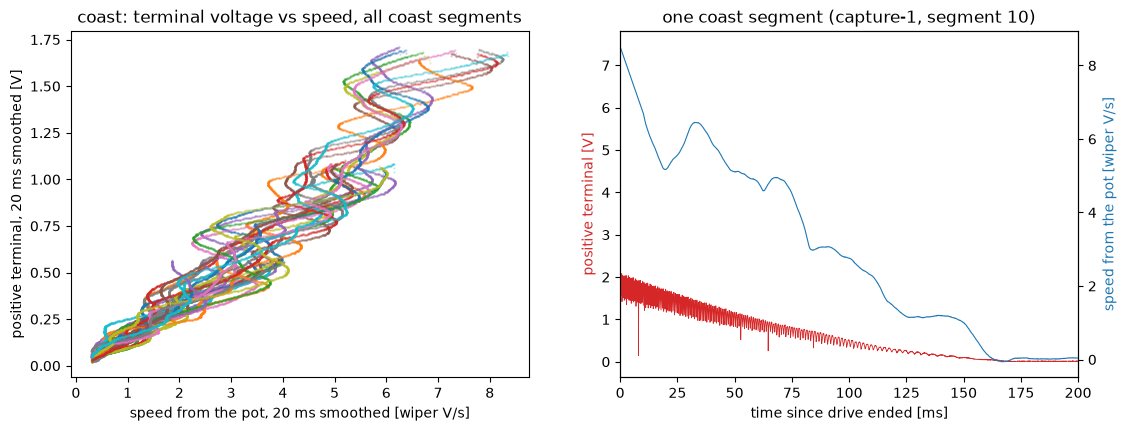

,slope_regression_s,intercept_V,slope_integral_s,segments
mean,0.2118,-0.0583,0.1966,6.0
min,0.2087,-0.0629,0.1941,6.0
max,0.2143,-0.0491,0.2022,6.0
count,5.0000,5.0000,5.0000,5.0


In [9]:
SG_WIN = 401   # 20 ms smoothing window for speed from the pot

def coast_segments(sweeps):
    # Per coast segment: time, position (wiper V, positive along the entry
    # direction), positive-terminal voltage, terminal sum in V.
    sp, meta = sweeps["spindown"]
    out = []
    for seg_id, seg in sp[sp["kind"] == "coast"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        pos_t = "vmotor_a" if d > 0 else "vmotor_b"
        out.append({
            "seg": seg_id,
            "t": np.arange(len(seg)) / TICK_HZ,
            "p": seg["pos"].to_numpy() * d * V_ADC_PER_COUNT,
            "e": seg[pos_t].to_numpy() * V_TERM_PER_COUNT,
            "sum": (seg["vmotor_a"] + seg["vmotor_b"]).to_numpy() * V_TERM_PER_COUNT,
            "shunt_offset": seg["current_raw"].to_numpy() - seg["bias"].iloc[0],
        })
    return out

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pts = []
for name, sweeps in recs.items():
    for c in coast_segments(sweeps):
        v = savgol_filter(c["p"], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
        es = savgol_filter(c["e"], SG_WIN, 2)
        i = np.arange(len(v))
        m = (i >= SG_WIN // 2) & (v > 0.3) & (c["sum"] < rails[name])
        axes[0].plot(v[m], es[m], ".", ms=1, alpha=0.3)
        pts.append(pd.DataFrame({"recording": name, "seg": c["seg"], "v": v[m], "e": es[m]}))
axes[0].set_xlabel("speed from the pot, 20 ms smoothed [wiper V/s]")
axes[0].set_ylabel("positive terminal, 20 ms smoothed [V]")
axes[0].set_title("coast: terminal voltage vs speed, all coast segments")
name, sweeps = next(iter(recs.items()))
c = coast_segments(sweeps)[2]
v = savgol_filter(c["p"], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
axes[1].plot(c["t"] * 1e3, c["e"], lw=0.6, color="tab:red", label="positive terminal [V]")
axes[1].set_xlabel("time since drive ended [ms]")
axes[1].set_ylabel("positive terminal [V]", color="tab:red")
ax2 = axes[1].twinx()
ax2.plot(c["t"] * 1e3, v, lw=0.8, color="tab:blue", label="speed (pot) [wiper V/s]")
ax2.set_ylabel("speed from the pot [wiper V/s]", color="tab:blue")
axes[1].set_xlim(0, 200)
axes[1].set_title(f"one coast segment ({name}, segment {c['seg']})")
plt.show()

pts = pd.concat(pts)
rows = []
for name, g in pts.groupby("recording"):
    k = np.polyfit(g["v"], g["e"], 1)
    # Ripple-immune route: the integral of the terminal voltage over the
    # segment divided by the travel is the slope, if E = k v.
    ratios = []
    for c in coast_segments(recs[name]):
        i = np.arange(len(c["e"]))
        m = (i >= 2) & (c["sum"] < rails[name])
        travel = np.median(c["p"][-1000:]) - np.median(c["p"][:3])
        ratios.append(np.sum(c["e"][m]) / TICK_HZ / travel)
    rows.append({"recording": name, "slope_regression_s": k[0], "intercept_V": k[1],
                 "slope_integral_s": np.mean(ratios), "segments": len(ratios)})
bemf_fit = pd.DataFrame(rows).set_index("recording")
bemf_fit.agg(["mean", "min", "max", "count"]).round(4)


Findings:

- The positive terminal follows the speed with a slope of 0.20 V per wiper
  V/s from the integral ratio and 0.21 from the regression, with a small
  negative intercept from the regression.
- The terminal voltage decays smoothly through the segment. The
  pot-derived speed rides on a ripple of about 30% amplitude with a period
  of roughly 0.1 V of wiper travel, visible in the right panel and as the
  loops in the left panel. The ripple is absent from the terminal
  voltage, so it is on the pot side of the gear train. *Hypothesis (not
  tested here): the ripple is a periodic error of the potentiometer track
  or of the final gear stage. Notebook 06 takes it up.*
- The slope is a property of the loaded terminal. Two equal 30 kOhm loads
  to ground share the back-EMF between the terminals, and the clamp on the
  negative side shifts that share. Notebook 03 compares this slope with
  the drive-side estimate. The motor-shaft constant needs the gear ratio
  (notebook 06).

The slope from the integral ratio is the one used below to convert
terminal volts into wiper V/s.

### 6.2 Coast deceleration vs speed

The model is Coulomb plus viscous friction,

$$\frac{dv}{dt} = -(a + b\,v), \qquad v > 0,$$

with $a$ in wiper V/s$^2$ and $b$ in 1/s. Two routes fit it. The pot
route fits the closed-form trajectory $p(t)$ of the model to the position
trace of every coast segment of a recording jointly, with one $(a, b)$
per recording and one entry speed per segment. The terminal route fits the
same model to the positive terminal voltage $E(t)$ of the same segments,
where $E$ stands in for speed, and converts $a$ with the slope of
section 6.1. The terminal route gives $b$ directly, since $b$ is a rate
and needs no unit conversion. The figure shows the measured speed of
every coast segment with the terminal-route model overlaid.


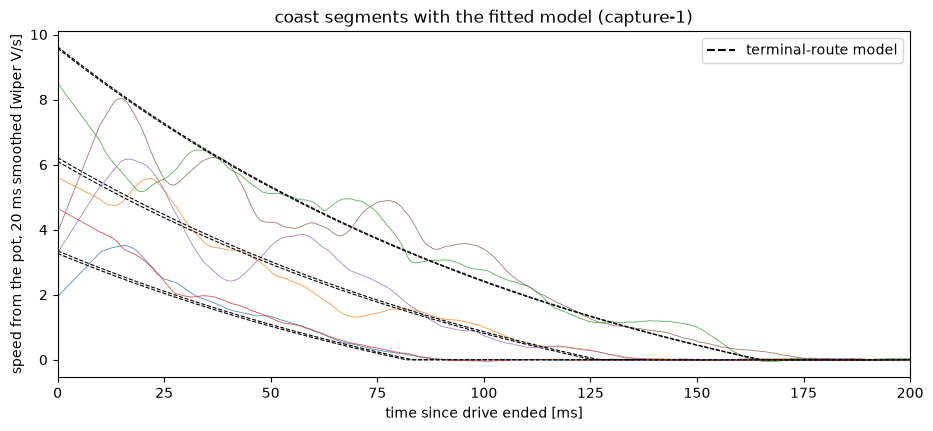

,pot route a [V/s2],pot route b [1/s],pot route rms resid [mV],terminal route a [V/s2],terminal route b [1/s],terminal route b se [1/s],terminal route rms resid [mV]
mean,41.76,0.87,4.29,27.90,7.49,0.05,57.89
min,37.87,0.00,4.20,25.98,7.24,0.05,57.02
max,46.02,1.93,4.46,28.54,7.82,0.05,59.26
count,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [10]:
FIT_N = 5000   # 250 ms of every zero-duty segment enters the fit

def traj(t, p0, v0, a, b):
    # Position under dv/dt = -(a + b v) from v0, at rest after t_stop.
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    tt = np.minimum(t, t_stop)
    return p0 + (v0 + a / b) * (1 - np.exp(-b * tt)) / b - (a / b) * tt

def speed_model(t, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    return np.where(t < t_stop, (v0 + a / b) * np.exp(-b * np.minimum(t, t_stop)) - a / b, 0.0)

def joint_fit(segs, signal, mask_fn, has_p0):
    # Shared (a, b), per-segment start value (and offset when has_p0).
    t = np.arange(FIT_N) / TICK_HZ
    per = 2 if has_p0 else 1
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            y = c[signal][:FIT_N]
            m = mask_fn(c)[:FIT_N]
            if has_p0:
                model = traj(t, x[2 + per * i], x[3 + per * i], x[0], x[1])
            else:
                model = speed_model(t, x[2 + i], x[0], x[1])
            r.append((model - y)[m])
        return np.concatenate(r)
    x0 = [30.0, 5.0]
    lb = [0.0, 0.0]
    for c in segs:
        y = c[signal]
        if has_p0:
            x0 += [y[0], 5.0]
            lb += [-np.inf, 0.0]
        else:
            x0 += [max(y[3], 0.1)]
            lb += [0.0]
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    se = np.sqrt(np.diag(cov))
    starts = res.x[3::2] if has_p0 else res.x[2:]
    return {"a": res.x[0], "b": res.x[1], "a_se": se[0], "b_se": se[1],
            "starts": starts, "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

coast_fits = {}
for name, sweeps in recs.items():
    segs = coast_segments(sweeps)
    slope = bemf_fit.loc[name, "slope_integral_s"]
    pot = joint_fit(segs, "p", lambda c: np.ones(len(c["p"]), bool), True)
    term = joint_fit(segs, "e", lambda c: (np.arange(len(c["e"])) >= 2) & (c["sum"] < rails[name]), False)
    coast_fits[name] = {"segs": segs, "pot": pot, "term": term, "slope": slope}

fig, ax = plt.subplots(figsize=(11, 4.5))
name, f = next(iter(coast_fits.items()))
t = np.arange(FIT_N) / TICK_HZ
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    vm = speed_model(t, f["term"]["starts"][i], f["term"]["a"], f["term"]["b"]) / f["slope"]
    ax.plot(t * 1e3, vm, "k--", lw=0.8)
ax.plot([], [], "k--", label="terminal-route model")
ax.set_xlim(0, 200)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 20 ms smoothed [wiper V/s]")
ax.set_title(f"coast segments with the fitted model ({name})")
ax.legend()
plt.show()

rows = []
for name, f in coast_fits.items():
    rows.append({
        "recording": name,
        "pot route a [V/s2]": f["pot"]["a"],
        "pot route b [1/s]": f["pot"]["b"],
        "pot route rms resid [mV]": f["pot"]["rms_resid"] * 1e3,
        "terminal route a [V/s2]": f["term"]["a"] / f["slope"],
        "terminal route b [1/s]": f["term"]["b"],
        "terminal route b se [1/s]": f["term"]["b_se"],
        "terminal route rms resid [mV]": f["term"]["rms_resid"] * 1e3,
    })
coast_tab = pd.DataFrame(rows).set_index("recording")
coast_tab.agg(["mean", "min", "max", "count"]).round(2)


Findings:

- The terminal route resolves both terms. The Coulomb term is about
  28 wiper V/s$^2$ and the viscous term about 7.5 1/s, with a standard
  error on $b$ well under 1 1/s and a spread of under 10% across
  recordings. At the highest entry speed of about 10 wiper V/s the viscous
  term contributes more than twice the Coulomb term to the deceleration,
  and the model curves in the figure bend accordingly.
- The pot route drives $b$ to under 2 1/s and absorbs almost everything
  into a constant deceleration of about 42 wiper V/s$^2$. The pot ripple
  of section 6.1 is larger than the curvature that separates the two
  terms over a single segment, so the pot route cannot tell them apart.
- The two routes agree on the average deceleration over a segment and
  disagree on its split. Section 6.4 tests the terminal-route parameters
  against the measured stopping distances, which the pot measures without
  ripple sensitivity.

### 6.3 Brake deceleration vs speed

In brake the winding is shorted through the low-side switches. The
back-EMF drives a current through the winding resistance and the switch
on-resistance, and the resulting torque opposes the motion in proportion
to speed, so the same model applies with a much larger $b$. The terminals
are at ground during brake, so only the pot route is available. The
friction is the same mechanism as in coast, so the fit first holds $a$
at the terminal-route coast value of the same recording and fits $b$ and
the entry speeds, then repeats with $a$ free as a check.


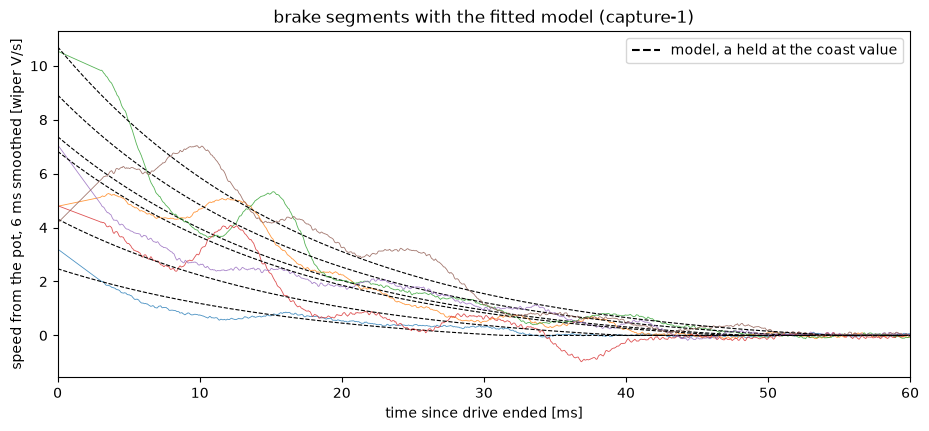

,a held [V/s2],"b, a held [1/s]",b se [1/s],"rms resid, a held [mV]",a free [V/s2],"b, a free [1/s]","rms resid, a free [mV]",brake/coast b ratio
mean,27.90,49.42,0.12,2.11,59.75,32.44,2.05,6.59
min,25.98,41.34,0.10,2.01,50.26,20.49,1.92,5.62
max,28.54,56.58,0.12,2.22,78.07,43.50,2.11,7.23
count,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [11]:
def brake_segments(sweeps):
    sp, meta = sweeps["spindown"]
    out = []
    for seg_id, seg in sp[sp["kind"] == "brake"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        out.append({
            "seg": seg_id,
            "t": np.arange(len(seg)) / TICK_HZ,
            "p": seg["pos"].to_numpy() * d * V_ADC_PER_COUNT,
            "vA": seg["vmotor_a"].to_numpy() * V_TERM_PER_COUNT,
            "vB": seg["vmotor_b"].to_numpy() * V_TERM_PER_COUNT,
        })
    return out

def brake_fit_fixed_a(segs, a_fixed):
    t = np.arange(FIT_N) / TICK_HZ
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            r.append(traj(t, x[1 + 2 * i], x[2 + 2 * i], a_fixed, x[0]) - c["p"][:FIT_N])
        return np.concatenate(r)
    x0 = [40.0] + sum([[c["p"][0], 5.0] for c in segs], [])
    lb = [0.0] + sum([[-np.inf, 0.0] for _ in segs], [])
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    return {"b": res.x[0], "b_se": np.sqrt(cov[0, 0]), "starts": res.x[2::2],
            "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

brake_fits = {}
for name, sweeps in recs.items():
    segs = brake_segments(sweeps)
    a_coast = coast_fits[name]["term"]["a"] / coast_fits[name]["slope"]
    fixed = brake_fit_fixed_a(segs, a_coast)
    free = joint_fit(segs, "p", lambda c: np.ones(len(c["p"]), bool), True)
    brake_fits[name] = {"segs": segs, "fixed": fixed, "free": free, "a_coast": a_coast}

fig, ax = plt.subplots(figsize=(11, 4.5))
name, f = next(iter(brake_fits.items()))
t = np.arange(FIT_N) / TICK_HZ
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], 121, 2, deriv=1, delta=1 / TICK_HZ)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    ax.plot(t * 1e3, speed_model(t, f["fixed"]["starts"][i], f["a_coast"], f["fixed"]["b"]),
            "k--", lw=0.8)
ax.plot([], [], "k--", label="model, a held at the coast value")
ax.set_xlim(0, 60)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 6 ms smoothed [wiper V/s]")
ax.set_title(f"brake segments with the fitted model ({name})")
ax.legend()
plt.show()

rows = []
for name, f in brake_fits.items():
    b_coast = coast_fits[name]["term"]["b"]
    rows.append({
        "recording": name,
        "a held [V/s2]": f["a_coast"],
        "b, a held [1/s]": f["fixed"]["b"],
        "b se [1/s]": f["fixed"]["b_se"],
        "rms resid, a held [mV]": f["fixed"]["rms_resid"] * 1e3,
        "a free [V/s2]": f["free"]["a"],
        "b, a free [1/s]": f["free"]["b"],
        "rms resid, a free [mV]": f["free"]["rms_resid"] * 1e3,
        "brake/coast b ratio": f["fixed"]["b"] / b_coast,
    })
brake_tab = pd.DataFrame(rows).set_index("recording")
brake_tab.agg(["mean", "min", "max", "count"]).round(2)


Findings:

- With $a$ held at the coast value, the brake viscous term is about
  50 1/s, five to seven times the coast value. The winding short adds
  electrical damping of that size on top of the mechanical friction.
- Freeing $a$ moves it up and $b$ down with almost no change in residual,
  the same trade-off seen in the pot route of section 6.2. The pot ripple
  sets this limit, and the brake segments are too short (20 to 40 ms) for
  the curvature to override it.
- The model misses the first few milliseconds of the fastest entries,
  where the measured speed drops faster than the fitted exponential. The
  ripple period at those speeds is close to the fit's time scale, so
  whether this is a real departure from the linear model is left open.

### 6.4 Stopping distance vs entry speed

For the fitted model the stopping distance from entry speed $v_0$ is

$$d(v_0) = \frac{v_0}{b} - \frac{a}{b^2}\ln\!\left(1 + \frac{b\,v_0}{a}\right).$$

The measured stopping distance of each zero-duty segment is the settled
position (median of the last 50 ms) minus the position at entry. The entry
speed comes from the fits above (the terminal route for coast, the held-a
fit for brake). The figure compares measured distances with the model
curve for both states, which is a check of the fitted parameters against
a quantity the pot measures without ripple sensitivity.


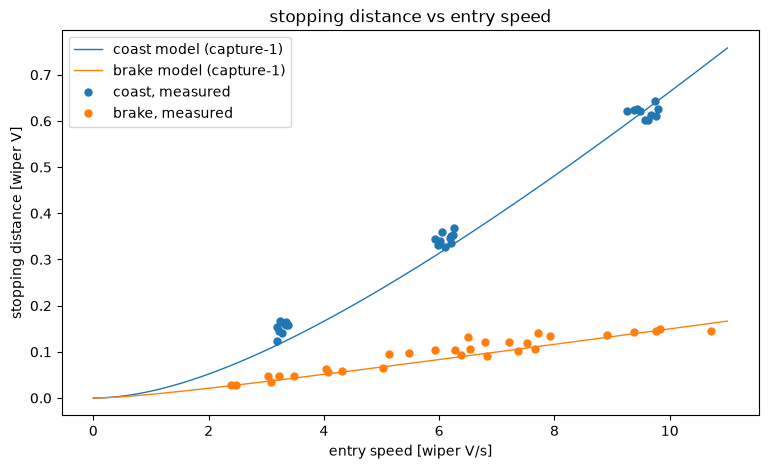

state             brake    coast
entry_Vps  min    2.386    3.182
           max   10.708    9.794
           mean   6.166    6.322
measured_V min    0.027    0.123
           max    0.150    0.642
           mean   0.095    0.373
model_V    min    0.028    0.117
           max    0.163    0.677
           mean   0.097    0.368
error_pct  min  -11.833  -24.312
           max   19.533    7.983
           mean   1.696   -5.970
stop_ms    min   31.372   81.761
           max   60.653  175.394
           mean  48.936  128.044

In [12]:
def stop_dist(v0, a, b):
    return v0 / b - a / b ** 2 * np.log1p(b * v0 / a)

rows = []
for name in recs:
    cf, bf = coast_fits[name], brake_fits[name]
    for i, c in enumerate(cf["segs"]):
        v0 = cf["term"]["starts"][i] / cf["slope"]
        a, b = cf["term"]["a"] / cf["slope"], cf["term"]["b"]
        rows.append({"recording": name, "state": "coast", "seg": c["seg"], "entry_Vps": v0,
                     "measured_V": np.median(c["p"][-1000:]) - np.median(c["p"][:3]),
                     "model_V": stop_dist(v0, a, b),
                     "stop_ms": np.log1p(b * v0 / a) / b * 1e3})
    for i, c in enumerate(bf["segs"]):
        v0 = bf["fixed"]["starts"][i]
        a, b = bf["a_coast"], bf["fixed"]["b"]
        rows.append({"recording": name, "state": "brake", "seg": c["seg"], "entry_Vps": v0,
                     "measured_V": np.median(c["p"][-1000:]) - np.median(c["p"][:3]),
                     "model_V": stop_dist(v0, a, b),
                     "stop_ms": np.log1p(b * v0 / a) / b * 1e3})
sd = pd.DataFrame(rows)
sd["error_pct"] = (sd["model_V"] / sd["measured_V"] - 1) * 100

fig, ax = plt.subplots(figsize=(9, 5))
vv = np.linspace(0, 11, 200)
name = next(iter(recs))
cf, bf = coast_fits[name], brake_fits[name]
ax.plot(vv, stop_dist(vv, cf["term"]["a"] / cf["slope"], cf["term"]["b"]), "-",
        color="tab:blue", lw=1, label=f"coast model ({name})")
ax.plot(vv, stop_dist(vv, bf["a_coast"], bf["fixed"]["b"]), "-",
        color="tab:orange", lw=1, label=f"brake model ({name})")
for state, color in [("coast", "tab:blue"), ("brake", "tab:orange")]:
    g = sd[sd["state"] == state]
    ax.plot(g["entry_Vps"], g["measured_V"], "o", color=color, ms=5, label=f"{state}, measured")
ax.set_xlabel("entry speed [wiper V/s]")
ax.set_ylabel("stopping distance [wiper V]")
ax.set_title("stopping distance vs entry speed")
ax.legend()
plt.show()

(sd.groupby("state")[["entry_Vps", "measured_V", "model_V", "error_pct", "stop_ms"]]
   .agg(["min", "max", "mean"]).round(3).T)


Findings:

- Coast stopping distances range from about 0.12 to 0.64 wiper V for
  entry speeds of 3 to 10 wiper V/s, with stop times up to about 175 ms.
  The terminal-route model matches the measured distances within 8% at
  the two higher entry speeds and underestimates them by up to 24% at the
  lowest, where the Coulomb term dominates. The high-speed agreement
  supports the split between the Coulomb and viscous terms that the pot
  route could not resolve. The low-speed shortfall says the friction
  near rest is below the fitted Coulomb term, which notebook 04 takes up.
- Brake stopping distances are about four times shorter at the same entry
  speed, 0.03 to 0.15 wiper V, with stop times of 30 to 60 ms.

## 7. Limitations and open issues

- **One unit, one supply.** All numbers describe this one servo on a
  2-cell battery. The gear train has prior wear.
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2).
- **Coast from high speed is absent.** The runway between the
  repositioning end and the far endstop is too short for a coast from
  above 40% duty at this supply, so the coast model is fitted below
  10 wiper V/s and extrapolated above.
- **Entry speeds vary.** Each drive step starts with residual motion from
  the repositioning move, so the entry speeds are measured, never
  commanded, and the spin-down segments do not pair up.
- **The pot speed ripple.** The pot-derived speed carries a ripple of
  about 30% that the terminal voltage does not show (section 6.1). Every
  fit that uses the pot alone is limited by it, in particular the split
  between Coulomb and viscous friction in section 6.2 and the whole of
  section 6.3.
- **The fast-decay coast reading is unexplained.** Section 5.3 shows what
  the crest-scan terminal reads in the 35% to 50% range and rules out
  back-EMF. The mechanism behind the reading is a hypothesis.
- **The sampling floors are this board's.** The 13.3% and 17.5% floors
  and the scan slot offsets change with board revision and firmware
  configuration.

## 8. What the next notebooks use from here

- The validity map of section 5.4, as the gate on every current and
  terminal sample by bridge state, decay mode and scan.
- The rail, the diode level and the discriminator threshold of section
  5.3, for separating the diode phase from the settled coast window.
- The coast terminal as a direct speed signal with the slope of section
  6.1, and the fact that the pot ripple is absent from it.
- The coast friction model of section 6.2 (Coulomb about 28 wiper V/s$^2$,
  viscous about 7.5 1/s) and the brake damping of section 6.3 (about
  50 1/s), as inputs to the friction and inertia notebooks.
- The rule that direct back-EMF comes from coast segments, since the
  fast-decay crest scan does not deliver it in this scan geometry.
